
# Entregable Aprendizaje No Supervisado DiploDatos 2025

## Grupo 33


## Clustering con base de datos del Fifa 2025


Comenzamos importando las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',1000)
import itertools
import warnings
warnings.filterwarnings("ignore")
import io

In [2]:
from plotly.offline import init_notebook_mode, plot,iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)
import matplotlib.pyplot as plt
import plotly.tools as tls#visualization
import plotly.figure_factory as ff#visualization
import seaborn as sns

In [3]:
from sklearn.cluster import KMeans,MeanShift
from sklearn import decomposition

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
from scipy.cluster.vq import whiten
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings

## Análisis exploratorio de datos

Carguemos los datos y veamos su estructura:

In [6]:
url='https://raw.githubusercontent.com/DiploDatos/AprendizajeNOSupervisado/master/2024/2025/male_players.csv'

df=pd.read_csv(url)
df.head(5)

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,97,93,94,90,83,84,84,83,78,69,86,71,80,93,93,82,93,92,88,38,73,26,34,32,88,88,77,64,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,83,81,80,91,90,85,86,77,74,90,66,68,89,89,73,89,82,79,91,89,87,82,75,77,79,77,84,93,77,85,CAM,4,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,69,95,95,87,89,81,83,73,71,85,81,62,83,77,79,93,94,84,86,90,83,26,50,32,25,18,74,84,65,58,LW,4,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


Veamos información de la base de datos, cuantos datos tiene cada columna y de qué tipo son:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16161 entries, 0 to 16160
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0.1           16161 non-null  int64  
 1   Unnamed: 0             16161 non-null  int64  
 2   Rank                   16161 non-null  int64  
 3   Name                   16161 non-null  object 
 4   OVR                    16161 non-null  int64  
 5   PAC                    16161 non-null  int64  
 6   SHO                    16161 non-null  int64  
 7   PAS                    16161 non-null  int64  
 8   DRI                    16161 non-null  int64  
 9   DEF                    16161 non-null  int64  
 10  PHY                    16161 non-null  int64  
 11  Acceleration           16161 non-null  int64  
 12  Sprint Speed           16161 non-null  int64  
 13  Positioning            16161 non-null  int64  
 14  Finishing              16161 non-null  int64  
 15  Sh

Veamos una descripción de las variables numéricas de la base:

In [8]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Rank,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Weak foot,Skill moves,Age,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
count,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,1816.000000,1816.000000,1816.000000,1816.000000,1816.000000
mean,8080.000000,8080.000000,8934.139657,66.172390,68.149558,54.146835,58.434874,63.599158,50.591981,65.241755,64.778727,64.812264,50.983293,46.680218,58.000990,46.934719,42.579543,47.614813,54.865107,49.554916,42.770621,59.507766,54.207165,48.118743,56.346946,63.664687,64.103088,62.223934,59.039787,58.299672,47.333271,51.868696,47.018873,48.879587,46.635542,66.173442,63.426892,65.317121,56.342986,2.952045,2.393292,25.790545,65.282489,63.281388,62.361784,63.645925,66.120595
std,4665.423186,4665.423186,5003.925857,6.761979,10.612153,13.740389,9.660646,9.262399,16.323879,9.509657,15.478648,15.258747,19.903044,19.912475,12.876878,19.479070,17.707794,15.710242,13.370436,17.922018,16.956133,14.183703,14.424724,18.084827,18.810193,15.097148,14.640849,8.757220,16.712129,12.155230,20.746819,17.371728,20.408949,20.979117,20.509403,11.755204,16.450390,12.370667,16.771384,0.677057,0.783739,4.662681,7.351546,7.019344,7.403049,8.026517,7.775521
min,0.000000,0.000000,1.000000,47.000000,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000,15.000000,15.000000,3.000000,3.000000,20.000000,5.000000,5.000000,10.000000,15.000000,8.000000,6.000000,13.000000,11.000000,7.000000,5.000000,19.000000,20.000000,30.000000,10.000000,15.000000,6.000000,6.000000,5.000000,9.000000,8.000000,27.000000,15.000000,26.000000,11.000000,1.000000,1.000000,17.000000,45.000000,45.000000,44.000000,41.000000,45.000000
25%,4040.000000,4040.000000,5037.000000,62.000000,62.000000,45.000000,52.000000,58.000000,36.000000,59.000000,57.000000,57.000000,40.000000,31.000000,48.000000,32.000000,30.000000,38.000000,46.000000,39.000000,31.000000,55.000000,46.000000,36.000000,51.000000,55.000000,56.000000,57.000000,55.000000,51.000000,27.000000,44.000000,30.000000,29.000000,27.000000,58.000000,57.000000,58.000000,46.000000,3.000000,2.000000,22.000000,60.000000,58.000000,57.000000,58.000000,61.000000
50%,8080.000000,8080.000000,9009.000000,66.000000,69.000000,57.000000,59.000000,64.000000,55.000000,66.000000,68.000000,68.000000,57.000000,51.000000,59.000000,51.000000,44.000000,49.000000,57.000000,54.000000,42.000000,63.000000,57.000000,50.000000,62.000000,66.000000,66.000000,62.000000,63.000000,60.000000,55.000000,55.000000,53.000000,57.000000,54.000000,68.000000,67.000000,66.000000,60.000000,3.000000,2.000000,25.000000,65.000000,63.000000,62.000000,64.000000,66.000000
75%,12120.000000,12120.000000,13135.000000,70.000000,75.000000,64.000000,65.000000,70.000000,64.000000,72.000000,75.000000,75.000000,65.000000,63.000000,68.000000,62.000000,56.000000,59.000000,65.000000,63.000000,55.000000,68.000000,64.000000,62.000000,68.000000,75.000000,74.000000,68.000000,69.000000,66.000000,64.000000,64.000000,64.000000,66.000000,63.000000,75.000000,74.000000,74.000000,69.000000,3.000000,3.000000,29.000000,70.000000,68.000000,67.000000,69.000000,71.000000
max,16160.000000,16160.000000,17717.000000,91.000000,97.000000,93.000000,94.00

Podemos observar que los datos contienen información sobre la identificación del jugador (un número y el nombre) y luego sobre los valores numéricos asignados en distintos atributos. El primero que aparece, 'OVR' es el puntaje promedio final, luego aparecen algunos como el ritmo 'PAC', el tiro 'SHO', el pase 'PAS', etc. Todos estos atributos contienen valores numéricos entre 0 y 99. Después aparece la variable de posición que diferencia las distintas posiciones dentro de la cancha. Hay otras 2 variables numéricas 'Weak foot' y 'Skill moves' que corresponden a habilidades y toman valores enteros desde 0 a 5. Finalmente, hay más variables que permiten describir al jugador pero no son numéricas, como su pierna hábil, nacionalidad, liga donde juega, etc.

Podemos notar algunas cosas importantes, como que todas las variables asociadas a las habilidades son numéricas y enteras. La mayoría (excepto las 2 mencionadas previamente) tienen la misma escala numérica (0-99) por lo que si usamos esas variables para un modelo capaz no es necesaria la normalización de datos, pero si pensamos agregar otra, ahí deberíamos normalizar para evitar que escalas más grandes tomen más importancia. Además, puede notarse que 'OVR' no es una variable independiente, sino que un "resumen" del resto.

Por último, es fácil notar que jugadores en distintas posiciones pueden tener habilidades muy distintas (por ejemplo, es esperable pensar que un delantero tendrá mejor tiro que un defensor) por lo que puede ser una variable útil para ver distintos clusters.

In [9]:
print("Tamaño del dataset")
print(df.shape)

print(" ")

print("Datos de faltantes por columna:")
print(df.isna().sum()[df.isna().sum() > 0])

print(" ")

print("Cantidad de arqueros")
print(len(df[df['Position'] == 'GK']))

Tamaño del dataset
(16161, 58)
 
Datos de faltantes por columna:
Alternative positions     7247
play style                8682
GK Diving                14345
GK Handling              14345
GK Kicking               14345
GK Positioning           14345
GK Reflexes              14345
dtype: int64
 
Cantidad de arqueros
1816


La base de datos contiene información sobre 16161 jugadores con 58 variables cada uno.

Además, podemos notar que las columnas con valores faltantes son, en su mayoría, habilidades correspondientes a los arqueros (que los jugadores de campo no tienen). También hay valores faltantes en 'play style' que intenta explicar la forma de juego de cada jugador y en 'Alternative positions' ya que existen jugadores con solo una posición fija.

Ahora que ya vimos la estructura general de los datos, podemos graficar el 'OVR' que, como dijimos previamente, es un buen resumen de las habilidades de cada jugador.

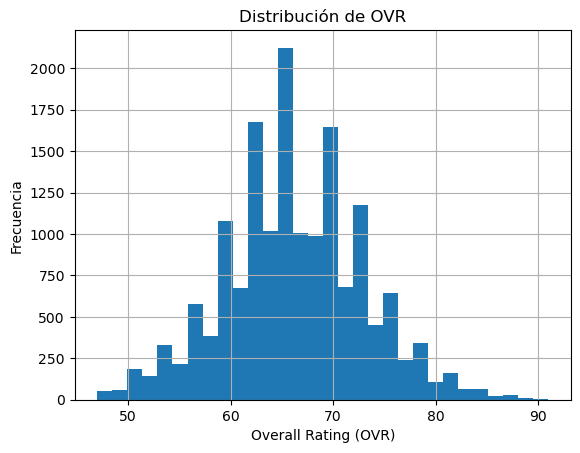

In [10]:
df['OVR'].hist(bins=30)
plt.xlabel("Overall Rating (OVR)")
plt.ylabel("Frecuencia")
plt.title("Distribución de OVR")
plt.show()

Podemos ver como casi todos los jugadores contienen un 'OVR' cerca de la media y hay unos pocos con valores cercanos a 90 y otros a 50.

Veamos también la correlación entre todas las variables de la base para poder elegir correctamente más tarde que variables utilizamos para el clustering.

In [11]:
# Eliminamos columnas que no aportan al análisis
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "Rank"])

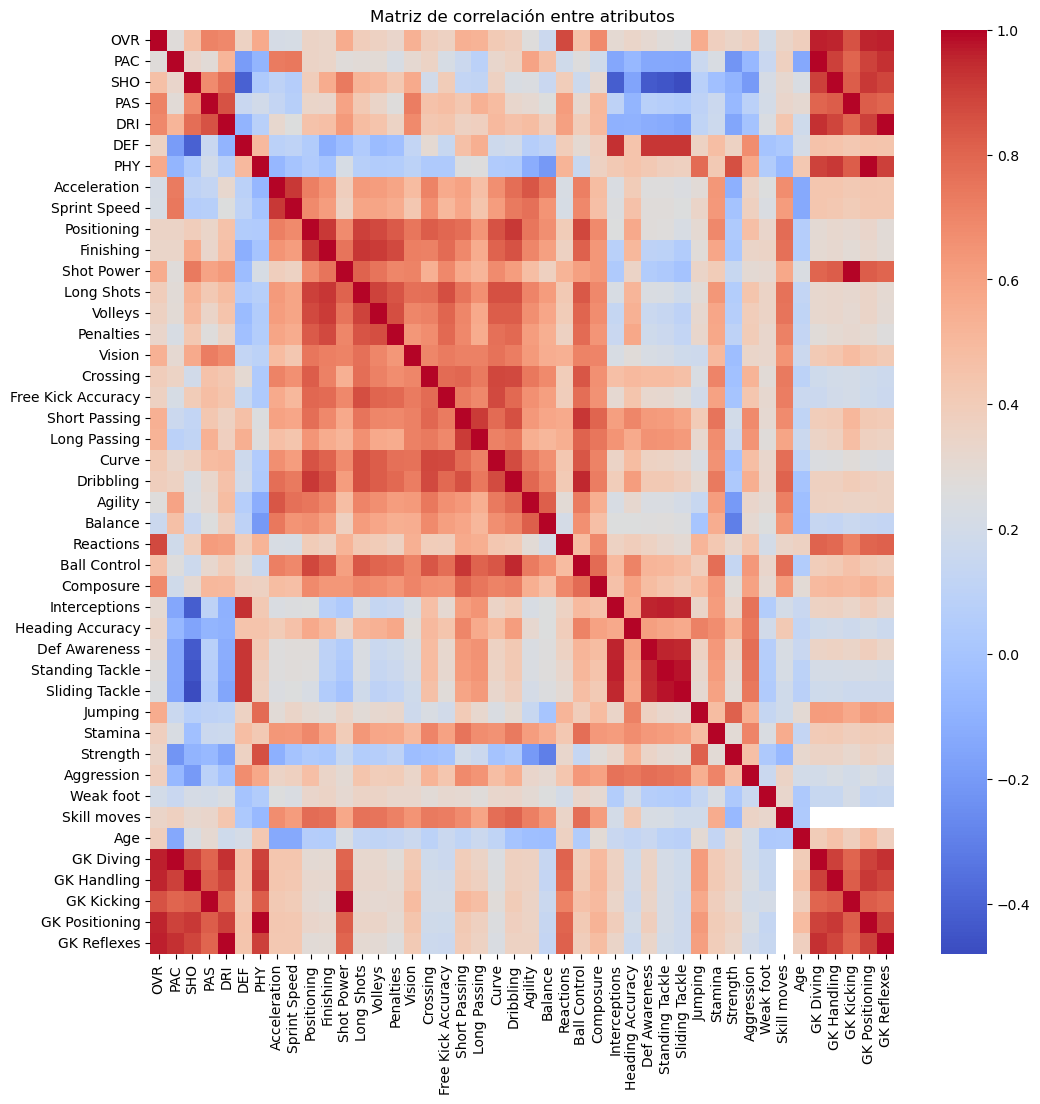

In [12]:
# Creamos la matriz de correlación
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación entre atributos")
plt.show()

Como último paso de esta exploración de datos, podemos ver en qué es mejor cada posición.

Por ejemplo, podemos ver que los mediocampistas son los mejores dando pases (CM y CAM corresponden a posiciones en la mitad de la cancha):

In [13]:
df.groupby('Position')[['SHO','DEF','PAS']].mean().sort_values('PAS', ascending=False)

,SHO,DEF,PAS
Position,,,
CM,58.194180,58.756085,64.402116
CAM,61.626431,43.977107,64.302810
GK,63.281388,35.488436,62.361784
CDM,52.371429,63.986466,61.652632
LM,60.740702,40.288223,61.175620
RM,60.527902,41.100446,61.110491
LW,61.944282,34.322581,60.521994
RW,61.644258,35.815126,60.212885
LB,46.250412,61.097199,58.322076


Por otro lado, los delanteros son los de mejor tiro (ST es delantero):

In [14]:
df.groupby('Position')[['SHO','DEF','PAS']].mean().sort_values('SHO', ascending=False)

,SHO,DEF,PAS
Position,,,
ST,65.820889,30.893266,54.267980
GK,63.281388,35.488436,62.361784
LW,61.944282,34.322581,60.521994
RW,61.644258,35.815126,60.212885
CAM,61.626431,43.977107,64.302810
LM,60.740702,40.288223,61.175620
RM,60.527902,41.100446,61.110491
CM,58.194180,58.756085,64.402116
CDM,52.371429,63.986466,61.652632


Y, obviamente, los defensores son los mejores defendiendo (CB es defensor central):

In [15]:
df.groupby('Position')[['SHO','DEF','PAS']].mean().sort_values('DEF', ascending=False)

,SHO,DEF,PAS
Position,,,
CB,36.475034,66.371067,50.033174
CDM,52.371429,63.986466,61.652632
RB,45.773614,61.483997,57.712724
LB,46.250412,61.097199,58.322076
CM,58.194180,58.756085,64.402116
CAM,61.626431,43.977107,64.302810
RM,60.527902,41.100446,61.110491
LM,60.740702,40.288223,61.175620
RW,61.644258,35.815126,60.212885


## Evaluación visual de a 2 variables

Hagamos los scatterplots diferenciando por las posiciones dentro de la cancha es la forma más trivial de separar jugadores.

In [16]:
skills = [
    "OVR", "PAC", "SHO", "PAS", "DRI", "DEF", "PHY",
    "Acceleration", "Sprint Speed",
    "Positioning", "Finishing", "Shot Power", "Long Shots", "Volleys", "Penalties",
    "Vision", "Crossing", "Free Kick Accuracy", "Short Passing", "Long Passing", "Curve",
    "Dribbling", "Agility", "Balance", "Reactions", "Ball Control", "Composure",
    "Interceptions", "Heading Accuracy", "Def Awareness", "Standing Tackle", "Sliding Tackle",
    "Jumping", "Stamina", "Strength", "Aggression"
]
df_skills=df[skills]

In [17]:
forwards=['RF', 'ST', 'LW', 'LF', 'RS', 'LS', 'RM', 'LM','RW']
midfielders=['RCM','LCM','LDM','CAM','CDM','LAM','RDM','CM','RAM','CF']
defenders=['RCB','CB','LCB','LB','RB','RWB','LWB']
goalkeepers=['GK']

def pos2(position):
    if position in forwards:
        return 'Forward'

    elif position in midfielders:
        return 'Midfielder'

    elif position in defenders:
        return 'Defender'

    elif position in goalkeepers:
        return 'GK'

    else:
        return 'nan'

In [18]:
forwards_area = ['ST', 'CF']
sides = ['RF', 'LW', 'LF', 'RS', 'LS', 'RW', 'LB','RB','LWB','RWB']
mid_def = ['CDM','LDM','RDM']


midfield_def = ['CDM','LDM','RDM']
midfield_off = ['CAM','LAM','RAM']
midfield_mix = ['CM','LCM','RCM']

defenders_central = ['RCB','CB','LCB']
defenders_sides = []

goalkeepers = ['GK']

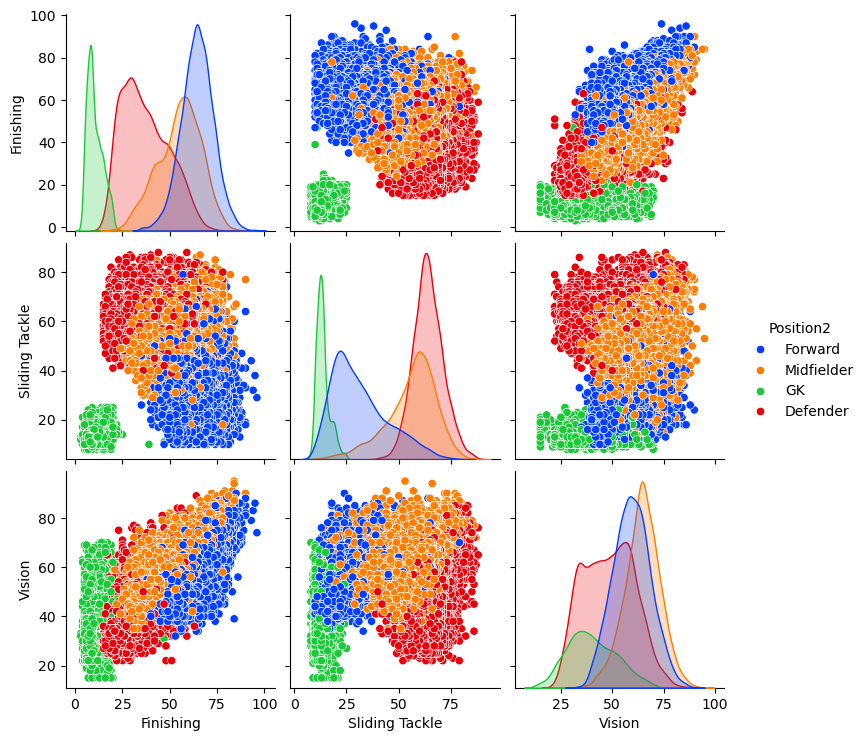

In [19]:
df["Position2"]=df["Position"].apply(lambda x: pos2(x))

df["Position2"].value_counts()

data_temp = df.loc[:,['Position2','Finishing','Sliding Tackle','Vision']]
sns.pairplot(data_temp, hue="Position2",palette='bright')

## ¿Normalización o escalado?

En clustering y proyecciones, la distancia es la medida principal, ya que se busca minimizar la distancia entre puntos dentro de un mismo cluster y maximizarla entre clusters vecinos. Por este motivo, es importante llevar las variables a una escala común. En nuestro caso, utilizamos únicamente variables de habilidad que ya se encuentran en el mismo rango (1 a 99), por lo que el escalado no sería estrictamente necesario. Sin embargo, como la varianza entre variables puede diferir, resulta recomendable aplicar un `StandardScaler` por precaución.

In [20]:
scaler = StandardScaler()

# Ajustamos y transformamos
df_skills_scaled = pd.DataFrame(
    scaler.fit_transform(df_skills),
    columns=df_skills.columns,
    index=df_skills.index
)

df_skills_scaled.head()

,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression
0,3.671762,2.718707,2.609407,2.232335,3.066346,-0.893932,1.341651,2.081724,2.109527,2.111135,2.376462,2.485074,1.851546,2.339181,2.316089,2.104327,1.587208,1.546944,1.867852,1.164206,1.762928,1.948634,1.943163,1.222434,3.514474,1.972294,2.443495,-0.449879,1.216457,-1.029917,-0.709279,-0.713624,1.856814,1.493817,0.944431,0.456566
1,3.671762,-0.202562,1.881604,2.853430,2.202612,2.230422,2.077768,0.014296,0.077842,1.256968,1.372036,2.640396,2.159579,1.605018,0.915685,2.179121,1.475610,1.252056,2.361391,2.550757,2.094708,1.470156,0.154691,0.197871,3.514474,1.852617,2.937125,1.767397,1.676989,2.204059,1.817121,1.724358,1.431458,1.676189,1.429464,1.708738
2,3.671762,1.870597,2.754968,1.197175,1.878712,-0.342575,2.393246,0.983403,1.912912,2.261870,2.476905,2.795718,1.851546,2.678026,2.698017,1.431179,0.471227,1.134101,1.233301,0.817568,1.597038,1.204334,0.883327,0.334479,3.628669,1.433746,2.361224,-0.208871,1.792123,-0.441921,-0.089596,-0.859903,2.197100,0.764328,2.237853,1.887620
3,3.523872,1.116721,2.391066,2.542882,2.634479,1.679066,1.867449,1.048010,0.995377,2.010644,2.175577,2.096770,2.005562,1.943863,1.679541,2.627886,0.917619,1.487967,2.079369,2.412102,1.375851,1.735977,1.214526,1.017521,3.286084,1.792778,2.361224,1.670994,1.331590,1.469064,1.435778,1.480560,1.516529,1.797770,0.944431,1.708738
4,3.523872,2.530238,2.172725,2.335850,2.958379,-1.322765,0.395215,1.952510,1.978450,1.809664,2.125356,1.786126,1.851546,1.717967,1.488577,2.253915,1.754605,1.134101,1.656335,1.580172,1.707631,1.948634,2.009403,1.359042,2.715108,1.852617,2.032137,-1.028299,-0.107574,-0.735919,-1.138290,-1.396259,0.665816,1.250654,-0.025636,0.098803


## Aplicación de Clustering

### K-means

Comenzamos haciendo un clustering con K-means.

Para esto, debemos elegir el número de clusters óptimo, es decir, el K. Un método para hacerlo es el "elbow method" (método del codo), que consiste en graficar la inercia para distintos K's y elegir el cual tenga un vértice (o codo).

Text(0.5, 1.0, 'Inertia of k-Means versus number of clusters')

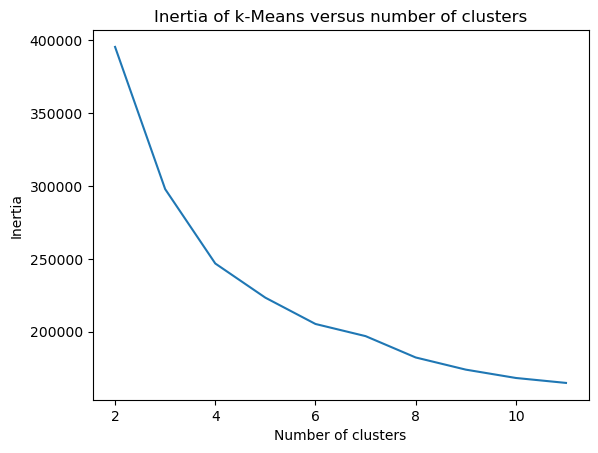

In [21]:
#Prueba: para elegir el hiperparámetro n_clusters, variando de 2 a 11 clusters
scores = [KMeans(n_clusters=i).fit(df_skills_scaled).inertia_ for i in range(2,12)]

plt.plot(np.arange(2, 12), scores)
plt.xlabel('Number of clusters')
plt.ylabel("Inertia")
plt.title("Inertia of k-Means versus number of clusters")

En el gráfico se ven algunos vértices (por ejemplo en K=2, K=4 y K=6). Para ver una segmentación más general podemos usar K=4. En el caso en el que quisieramos segmentar más, podríamos usar K=6.

In [22]:
# Número de clusters buscado
n_clust = 4

km = KMeans(n_clusters=n_clust,random_state=5)
km.fit(df_skills_scaled) # Utiliza todas las habilidades

# Etiquetas asignadas por el algoritmo
clusters = km.labels_
print('Suma de los cuadrados de las distancias al centro de cada cluster=Inertia= ', km.inertia_)

Suma de los cuadrados de las distancias al centro de cada cluster=Inertia=  246787.0220450928


In [23]:
df_clusters=df.copy()
df_clusters['kmeans_4'] = km.labels_
df_clusters.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Position2,kmeans_4
0,Kylian Mbappé,91,97,90,80,92,36,78,97,97,93,94,90,83,84,84,83,78,69,86,71,80,93,93,82,93,92,88,38,73,26,34,32,88,88,77,64,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Forward,0
1,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Midfielder,0
2,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Forward,0
3,Jude Bellingham,90,80,87,83,88,78,83,81,80,91,90,85,86,77,74,90,66,68,89,89,73,89,82,79,91,89,87,82,75,77,79,77,84,93,77,85,CAM,4,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Midfielder,0
4,Vini Jr.,90,95,84,81,91,29,69,95,95,87,89,81,83,73,71,85,81,62,83,77,79,93,94,84,86,90,83,26,50,32,25,18,74,84,65,58,LW,4,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Forward,0


In [24]:
#Elijo dos números entre 0 y  de n_skills-1
skill_1="Dribbling"
skill_2="SHO"

In [25]:
kmean_clusters = go.Scatter(x=df_skills[skill_1], y=df_skills[skill_2],
                           mode='markers',
                           text=df.loc[:,'Name'],
                           marker=dict(
                                size=5,
                                color = clusters.astype(float), #set color equal to a variable
                                colorscale='Portland',
                                showscale=False)
                           )

# Add cluster centers to the plot
cluster_centers = km.cluster_centers_

# Inverse transform the cluster centers
cluster_centers_original_scale = scaler.inverse_transform(cluster_centers)

centroids = go.Scatter(x=cluster_centers_original_scale[:, skills.index(skill_1)],
                       y=cluster_centers_original_scale[:, skills.index(skill_2)],
                       mode='markers+text',
                       marker=dict(
                           size=20,
                           color='white',
                           symbol='circle'
                       ),
                       text=[str(i) for i in range(n_clust)],
                       textposition='middle center',
                       name='Cluster Centers')


data=[kmean_clusters, centroids]

layout = go.Layout(
    title=dict(
        text="Clustering K means ",
        font=dict(size=20)
    ),
    xaxis=dict(title=skill_1),
    yaxis=dict(title=skill_2),
    autosize=False,
    width=1000,
    height=650
)

fig = go.Figure(data=data, layout=layout)

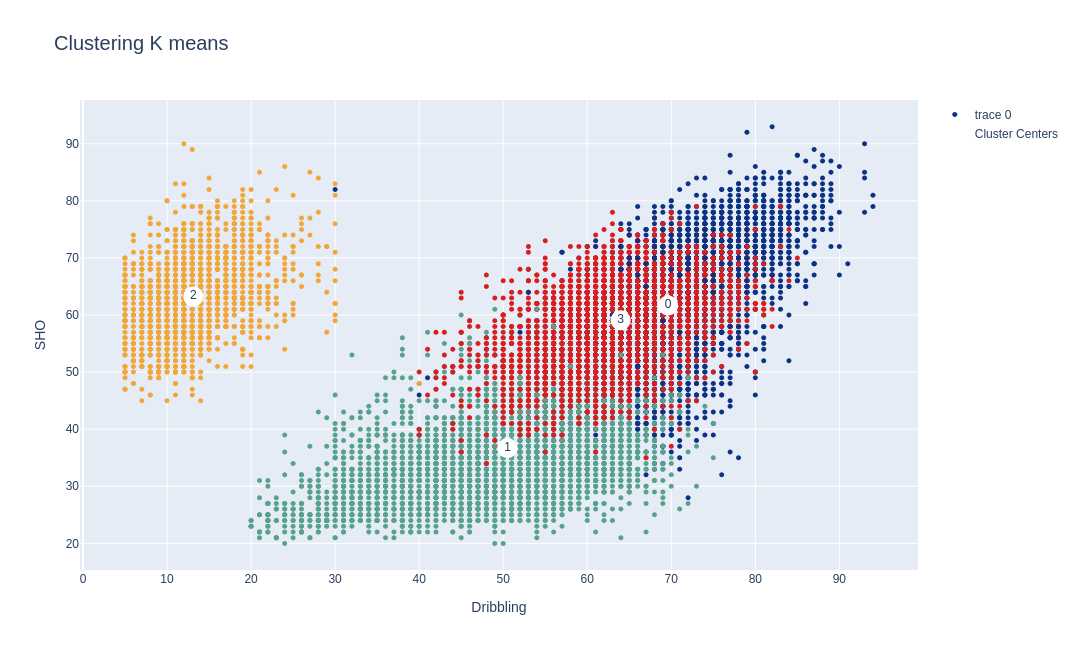

In [26]:
fig.show()

<Axes: xlabel='kmeans_4', ylabel='count'>

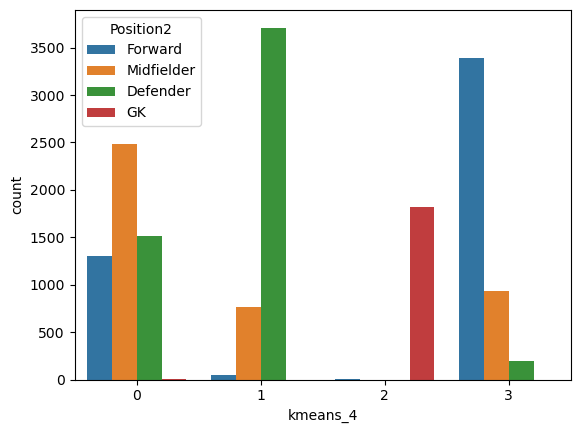

In [27]:
sns.countplot(df_clusters,x="kmeans_4",hue="Position2")

Podemos ver que en el cluster 2 aparecen solo los arqueros, en el 1 la mayoría son defensores y en el 3 la mayoría son delanteros. Por otra parte, el cluster 0 tiene más mediocampistas pero también una cantidad considerable de defensores y delanteros. Esto es lógico ya que el mediocampista puede tener características similares a defensores y atacantes. Capaz elegir K=6 permite diferenciar entre mediocampistas más defensivos, mediocampistas justo en el centro del campo y mediocampistas más atacantes.

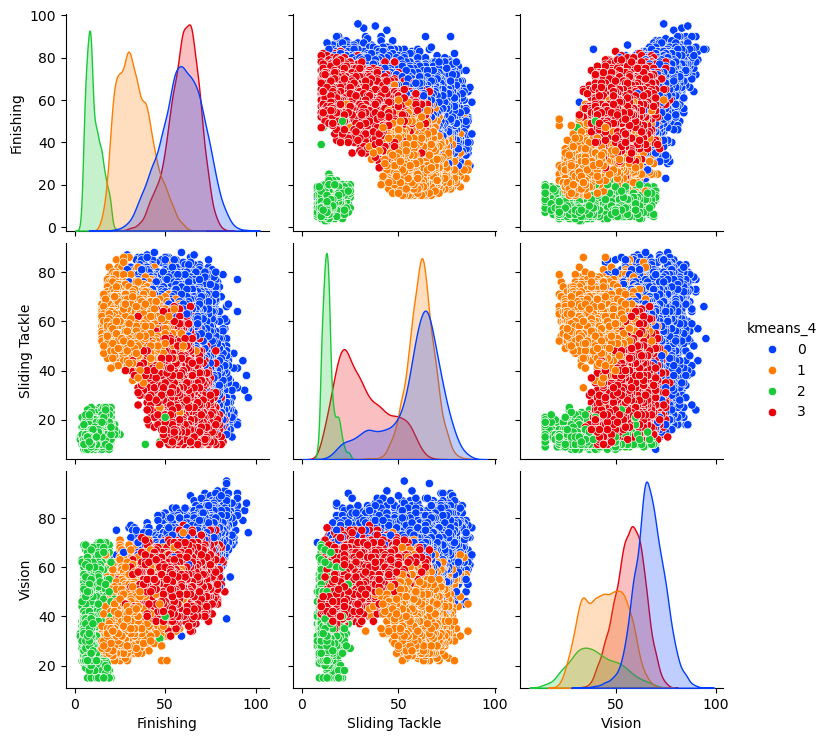

In [28]:
data_temp = df_clusters.loc[:,['kmeans_4','Finishing','Sliding Tackle','Vision']]


sns.pairplot(data_temp, hue="kmeans_4",palette='bright')

### Clustering jerárquico

Ahora vamos a hacer un clustering jerárquico que agrupa los datos en un árbol de clústeres anidados.

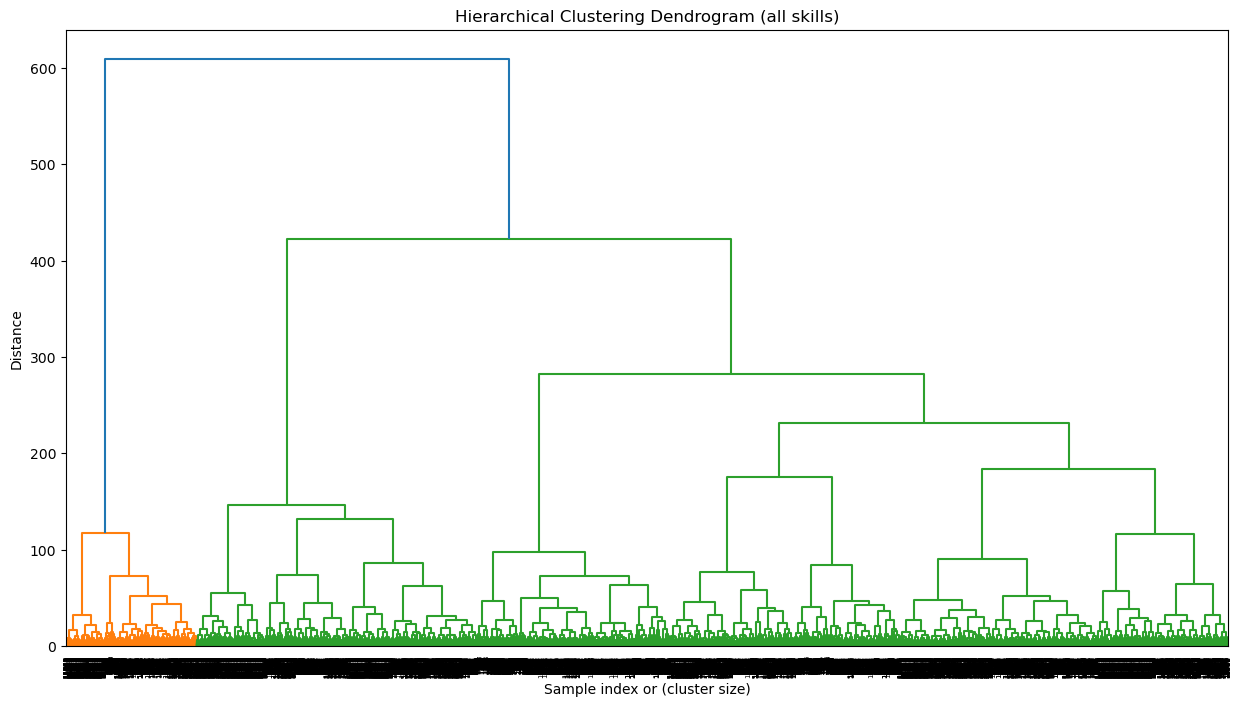

In [29]:
warnings.filterwarnings('ignore')

# Fit the data into hierarchical clustering algorithm using all scaled skills
dm = linkage(df_skills_scaled, method='ward')

# Create a dendrogram
plt.figure(figsize=(15,8))
dendr = dendrogram(dm)
plt.title("Hierarchical Clustering Dendrogram (all skills)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.show()

Debemos elegir el umbral para poder visualizar hacia arriba en el dendograma y tomar que corresponden al mismo cluster. Para eso, hay que ver el eje y del dendograma. Podemos ver que a la izquierda se forma un cluster (el naranja), al lado suyo otro cluster y luego a la derecha hay distintos clusters. Si elegimos la distancia = 250 entonces los clusters de la derecha serán 2 y tendríamos un total de 4 clusters.

In [30]:
# Definir el threshold para ver en el dendograma
distance_threshold = 250
hierarchical_clusters = fcluster(dm, t=distance_threshold, criterion='distance')

# Add the hierarchical cluster labels to the original DataFrame
df_clusters['hierarchical'] = hierarchical_clusters

<Axes: xlabel='hierarchical', ylabel='count'>

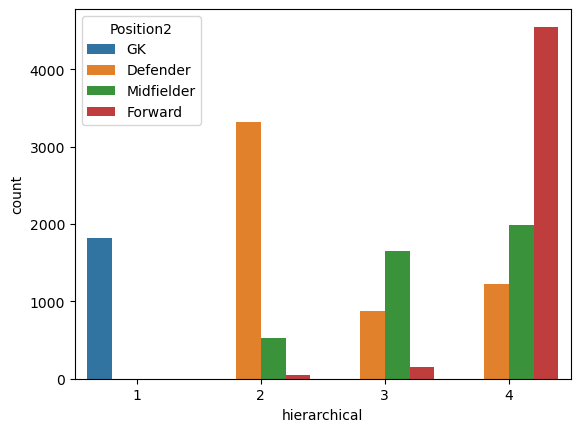

In [31]:
sns.countplot(df_clusters,x="hierarchical",hue="Position2")

Podemos ver nuevamente que separa de forma parecida a K-means. Los arqueros se encuentran totalmente en un cluster, los defensores y delanteros dominan su cluster y el cluster que menos diferenciado es el de los mediocampistas (el 3).

En base a los resultados obtenidos en los clustering de k-means y jerarquico podemos desarrollar lo siguiente:

*   **Cluster 0:** Este clúster es el más heterogéneo en términos de posiciones, aunque predominan los **mediocampistas** (Midfielder) hay una considerable cantidad de defensores y delanteros. En cuanto a las habilidades veremos valores intermedios de la mayoría de los atribbutos den comparacíon con los otros clústeres. La razon de esta heterogeneidad se debe a los mediocampistas y su rango amplio de habilidades, que a su vez les permite cumplir los roles de defensores o delanteros.  

*   **Cluster 1:** Definido por los **defensores** (Defender). Las habilidades de mayor valor son 'Def Awareness', 'Standing Tackle' y 'Sliding Tackle.

*   **Cluster 2:** Este clúster está compuesto casi exclusivamente por **arqueros** (GK) donde destacan GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes.

*   **Cluster 3:** Las habilidades de mayor puntaje aqui son 'Finishing', 'Shot Power', 'Positioning' y 'Dribbling', que caracterizan a los **delanteros** (Forward).

Respecto a si son equivalentes dentro de un cluster, entendemos de que si lo son. El más notorio es el de los medio campistas que pueden tomar la posicion de los defensores o delanteros.

Las diferencias en el tamaño de los clústeres están directamente relacionadas con la distribución real de las posiciones de los jugadores en el conjunto de datos.Es esperable que haya menos arqueros (Clúster 2) en comparación con los jugadores de campo (defensores, mediocampistas y delanteros). La cantidad de jugadores en cada posición en el dataset influye en cuántos jugadores terminan siendo agrupados en los clústeres que representan predominantemente esas posiciones.

**Transformacion/embedding apartir de PCA.**
Aplicamos Análisis de Componentes Principales a los datos para reducir la dimensionalidad a 2 componentes y visualizar los clústeres encontrados por k-means en este espacio reducido.


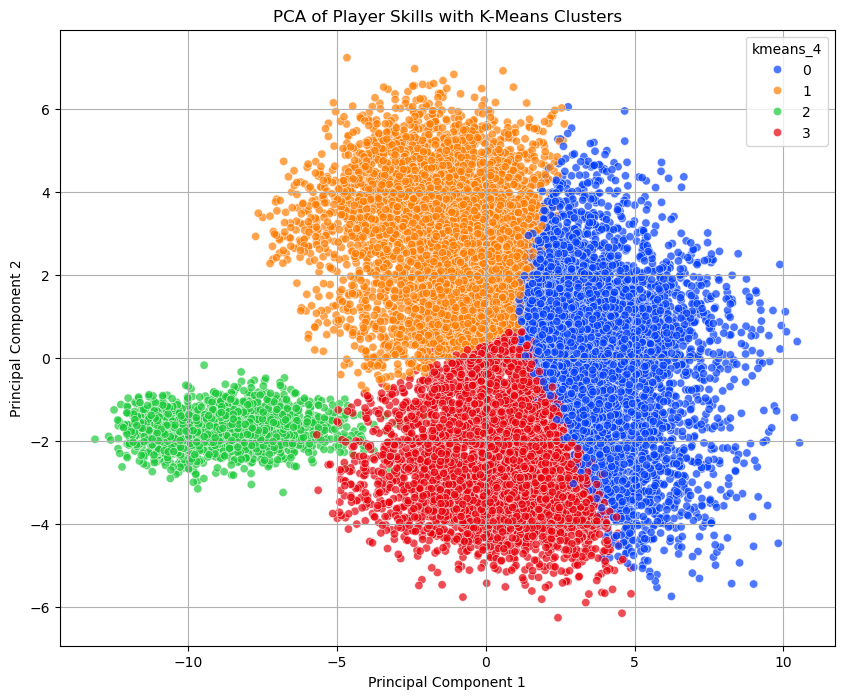

In [33]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
df_skills_pca = pca.fit_transform(df_skills_scaled)
df_pca = pd.DataFrame(df_skills_pca, columns=['PCA1', 'PCA2'])
df_pca['kmeans_4'] = df_clusters['kmeans_4']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='kmeans_4', palette='bright', alpha=0.7)
plt.title('PCA of Player Skills with K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

Ahora aplicaremos k-means a estos datos transformados, para ver si el espacio de menor dimensión produce resultados similares o no.

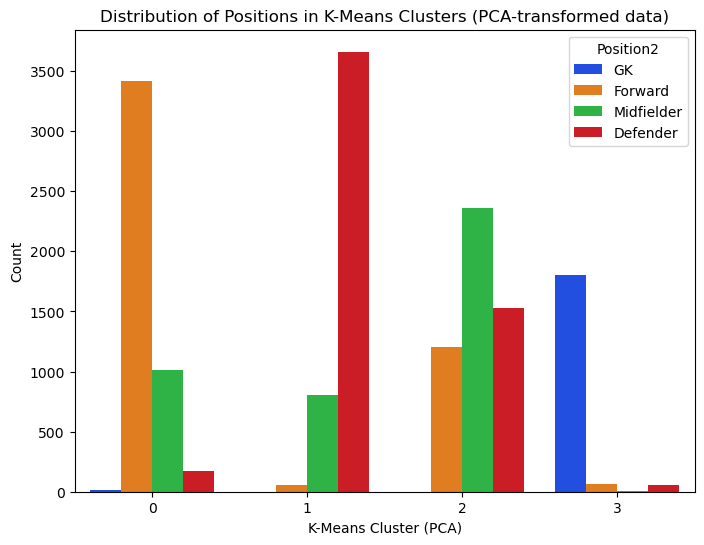

In [34]:
km_pca = KMeans(n_clusters=n_clust, random_state=5)
km_pca.fit(df_skills_pca)
df_pca['kmeans_pca_4'] = km_pca.labels_


plt.figure(figsize=(8, 6))
sns.countplot(data=df_pca, x='kmeans_pca_4', hue=df_clusters['Position2'], palette='bright')
plt.title('Distribution of Positions in K-Means Clusters (PCA-transformed data)')
plt.xlabel('K-Means Cluster (PCA)')
plt.ylabel('Count')
plt.show()

Comparando los resultados del clustering K-means aplicado a los datos de habilidades escaladas originales y a los datos transformados por PCA a 2 componentes, vemos que como el clustering en el espacio de PCA fue similar al original, sugiere que los dos primeros componentes principales capturan gran parte de la varianza relevante para la diferenciación de jugadores.
Esto sugiere que, para este dataset y este objetivo de clustering basado en posiciones generales, PCA a 2 componentes es una buena representación de los datos originales en términos de estructura de clústeres. Pero si quiesieramos identificar subgrupos dentro de cada posocion podria no aportar mucho el PCA.